# 1.1.1 边界、状态与观测

## 学习目标与先修知识

- 依据问题选择系统边界（system boundary），说明包含和忽略哪些对象。
- 区分状态（state）、观测（observation）、输入（input）与参数（parameter）。
- 用简单测量关系展示同一组读数可以对应不同解释。

**先修知识**：Python 列表、循环与函数；中学代数的移项。

## 具体问题

一个人运动后测得体表温度下降，能否立刻说“体内每一处都降温了”？不能。我们必须先确定研究的是体表、体内平均量，还是某个器官；还要说明测量装置读到什么。

假设仪器读数 y 比被测温度 x 高 0.3 °C。去掉这个偏移后，两次读数之间的差会改变吗？先预测，再用减法核对。

In [1]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
readings = [37.4, 37.1, 36.9]  # 人工温度读数，°C
offset = 0.3                     # 假定已知的偏移，°C
estimates = [value - offset for value in readings]
display(Markdown(show_table(['观测顺序', '读数 y / °C', '推断 x / °C'],
                           zip(range(1, 4), readings, estimates))))

Matplotlib is building the font cache; this may take a moment.


| 观测顺序 | 读数 y / °C | 推断 x / °C |
| --- | --- | --- |
| 1 | 37.4 | 37.1 |
| 2 | 37.1 | 36.8 |
| 3 | 36.9 | 36.6 |

## 模型假设

模型（model）是为某个问题保留必要关系的表示。这里把 x 看成所关注系统的状态，用 y 表示实际可见的观测。状态是模型为概括系统当前情况、描述后续演化而保留的一组变量，并非所有内部量都是状态。在已给定演化规则的确定性模型中，当前状态与未来输入一起决定后续演化；状态不一定能直接测量。

| 角色 | 在这个例子中的含义 | 单位与约定 |
|---|---|---|
| 系统 | 被概括成一个温度的内部对象 | 不追踪空间差异 |
| 状态 x | 模型要描述的内部温度 | °C |
| 观测 y | 仪器读数 | °C |
| 参数 b | 在本次观察中假定不变的偏移 | °C；本次取 0.3 |
| 输入 u | 例如来自环境的影响 | 环境温度可用 °C |

用 y=x+b 表示读数与被测温度的关系，假设偏移 b 固定、测量无随机误差。已知 b，就可以由读数求出 x。

边界也随问题改变：研究血液中的所追踪物质总量（tracked amount）时，血液到组织属于输出；研究血液和组织的合量时，同一移动属于内部转移。边界划在哪里，决定“进入”和“离开”的意义。

## 数学解释与推导

从 $y=x+b$ 两侧减去同一个量 b，得到 $x=y-b$。如果 b 已知，就可据此计算 x；如果 b 不知道，则同一个 y 可以由多组 x、b 组成。

例如 y=37.4 可以由 x=37.1、b=0.3 得到，也可以由 x=36.8、b=0.6 得到。这说明“能记录 y”不等于“已确定 x”。

图中横坐标表示三次观测的顺序。Matplotlib 的 `plot(横坐标, 纵坐标)` 画出这些数值，`label` 为每组数据命名；连线帮助比较两组读数的差。

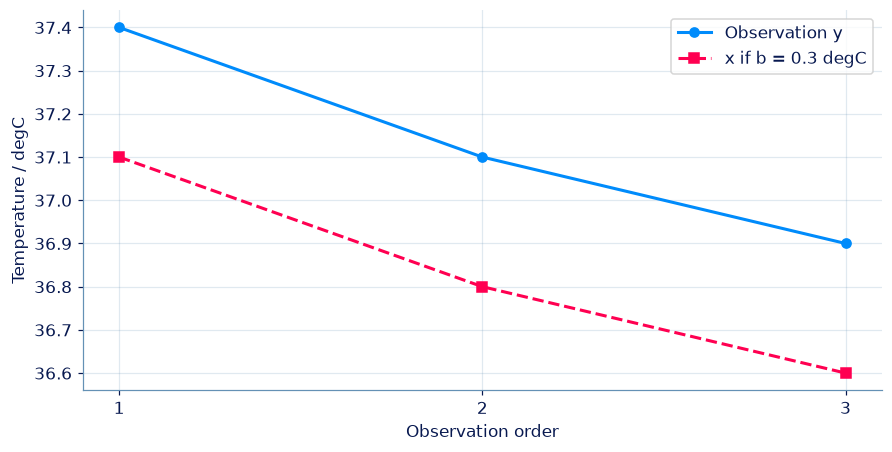

In [2]:
def infer_internal(readings, offset):
    return [value - offset for value in readings]

order = [1, 2, 3]
fig, ax = plt.subplots()
ax.plot(order, readings, 'o-', label='Observation y')
ax.plot(order, infer_internal(readings, 0.3), 's--', label='x if b = 0.3 degC')
ax.set(xlabel='Observation order', ylabel='Temperature / degC', xticks=order)
ax.legend()
plt.show()

## 对照实验

只改变测量假设 b=0.3 → b=0.6，保留所有读数。两种解释能否都还原原来的观测？这里比较的是解释，不是再次采集了温度。

In [3]:
for assumed_offset in [0.3, 0.6]:
    inferred = infer_internal(readings, assumed_offset)
    rebuilt = [x + assumed_offset for x in inferred]
    assert all(abs(a-b) < 1e-12 for a, b in zip(readings, rebuilt))
    print(f'b={assumed_offset:.1f} °C 时，推断值为 {[round(x, 2) for x in inferred]}')

# 同一偏移不改变两次读数之差。
assert abs((readings[1]-readings[0]) - (estimates[1]-estimates[0])) < 1e-12

b=0.3 °C 时，推断值为 [37.1, 36.8, 36.6]
b=0.6 °C 时，推断值为 [36.8, 36.5, 36.3]


## 结果解释

两种假设都能还原读数，因此这些读数本身不能替我们选择偏移量。独立标定或另一种测量可以增加信息。相同的单位使量可比较，却不使状态与观测自动相等。

把问题说清楚，至少要指出对象、时间或观察范围、可测量结果以及可能反驳预测的情况。“4 小时内同一培养孔的可见细胞数是否增加”比“生命为什么总能适应”更容易进入计算，但计数增加仍不能唯一证明分裂机制。

[本章导览与各节入口](http://127.0.0.1:8000/chapters/01-01-从生理现象提出系统问题/)

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 多项选择题：边界由问题决定

研究对象是一次人工物质转移实验。系统边界（system boundary）可以只包围血液，也可以同时包围血液和组织。以下哪些判断合理？

- **A.** 只包围血液时，血液到组织的转移是跨边界输出。
- **B.** 包围血液和组织时，两者之间的转移仍是整个系统的外部损失。
- **C.** 选择边界之前，应明确要解释哪个量在什么时间内的变化。
- **D.** 无论研究目的如何，包含的对象越多，模型（model）一定越好。

[作答：边界由问题决定](http://127.0.0.1:8000/chapters/01-01-%E4%BB%8E%E7%94%9F%E7%90%86%E7%8E%B0%E8%B1%A1%E6%8F%90%E5%87%BA%E7%B3%BB%E7%BB%9F%E9%97%AE%E9%A2%98/practice/?question=p01-boundary)

### 第 2 题 · 单项选择题：体温读数等于内部状态吗

一个简化模型（model）把内部温度 x 作为状态（state），体表读数 y 作为观测（observation），环境温度 u 作为输入（input），传热系数 k 作为参数（parameter）。哪项说法最合适？

- **A.** x 与 y 都用 °C，因此一定相等。
- **B.** k 一定随每次读数改变，否则不能解释任何变化。
- **C.** 需要说明从 x 和环境条件得到 y 的测量关系，才能用读数推断内部温度。
- **D.** u 是环境变量，所以不能影响所选系统。

[作答：体温读数等于内部状态吗](http://127.0.0.1:8000/chapters/01-01-%E4%BB%8E%E7%94%9F%E7%90%86%E7%8E%B0%E8%B1%A1%E6%8F%90%E5%87%BA%E7%B3%BB%E7%BB%9F%E9%97%AE%E9%A2%98/practice/?question=p01-state-observation)

### 第 3 题 · Python 计算题：去除已知的读数偏移

在人工测量模型（model） y = x + b 中，观测（observation）y 比内部量 x 多一个已知常数 b。给定一组读数和偏移量，返回模型推断的 x。这里不包含随机误差。

**函数与代码模板**

```python
def solve(
    readings: list[float],
    offset: float,
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `readings` | `list[float]` | 依次记录的温度读数 y。 | °C |
| `offset` | `float` | 已知偏移 b；可为负数。 | °C |

**返回值**

直接返回 estimates（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `estimates` | `list[float]` | 按输入（input）顺序返回每个 y − b。 | °C |

**计算规则**

逐项计算 readings[i] − offset；不取平均、不排序、不改变输入列表。

**约束与边界**

- 所有数值均为有限数。
- 0 ≤ len(readings) ≤ 1000；读数和偏移的绝对值不超过 100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| readings | 依次记录的温度读数 y。 | [37.4, 37.1] | °C |
| offset | 已知偏移 b；可为负数。 | 0.3 | °C |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
readings = [37.4, 37.1]
offset = 0.3

result = solve(readings, offset)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| estimates | 按输入（input）顺序返回每个 y − b。 | [37.1, 36.8] | °C |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [37.1, 36.8]
```

**样例解释**

已知读数均多了 0.3 °C，因此两次分别减去 0.3；得到 37.1、36.8 °C。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：去除已知的读数偏移](http://127.0.0.1:8000/chapters/01-01-%E4%BB%8E%E7%94%9F%E7%90%86%E7%8E%B0%E8%B1%A1%E6%8F%90%E5%87%BA%E7%B3%BB%E7%BB%9F%E9%97%AE%E9%A2%98/practice/?question=p01-calibrate)

### 第 4 题 · 单项选择题：提出可检验的问题

准备每小时拍摄同一个培养孔，共观察 4 小时。哪一个关于细胞数量的问题具有明确范围，且没有把待解释的机制直接当成事实？

- **A.** 细胞为什么总是完美适应环境？
- **B.** 既然所有增长都由营养导致，怎样证明它？
- **C.** 为什么生命会变化？
- **D.** 在计数规则不变时，0—4 小时的可见细胞数是否增加？若不增加，便反驳“这段时间必然增加”的预测。

[作答：提出可检验的问题](http://127.0.0.1:8000/chapters/01-01-%E4%BB%8E%E7%94%9F%E7%90%86%E7%8E%B0%E8%B1%A1%E6%8F%90%E5%87%BA%E7%B3%BB%E7%BB%9F%E9%97%AE%E9%A2%98/practice/?question=p01-cell-question)

**进一步阅读**

[Feedback Systems 第二版资料页](https://www.cds.caltech.edu/~murray/FBS/Second_Edition.html)第 3 章的 Modeling Concepts 是建模概念的拓展入口。[MIT 15.871 Assignment 3，B 部分](https://ocw.mit.edu/courses/15-871-introduction-to-system-dynamics-fall-2013/b950bd7b4f565b7b19145fb16bd55c8e_MIT15_871F13_ass3.pdf)讨论边界如何随建模目的选择。